## PARAM

In [1]:
import numpy as np
import pandas as pd
from sklearn import metrics
import tensorflow as tf
from tensorflow.keras import layers
import torch
import math
import pickle
import numpy as np
from sklearn.model_selection import KFold
from tqdm import tqdm 
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

In [2]:
SEQ_LENGTH = 15 
NUM_FEATURE = 1024 
HIDDEN_DIM = 512          # Adjusted for balance between complexity and generalization
BATCH_SIZE = 32            # Moderate batch size for stable training
NUM_HEADS = 8              # Reverted to original for better feature diversity
NUM_ENCODER_LAYERS = 2     # Reduced to avoid overfitting on positive class
DROPOUT = 0.2   
EPOCHS = 25 
K_FOLD=5
NUM_CLASSES = 2
VALIDATION_MODE="cross" # cross or independent

In [3]:
import numpy as np
x_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/train_data.npy", allow_pickle=True)
y_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/train_labels.npy", allow_pickle=True)
x_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/test_data.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/test_labels.npy", allow_pickle=True)

In [4]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test .shape)

(86214, 1, 15, 1024)
(86214, 2)
(21208, 1, 15, 1024)
(21208, 2)


In [5]:
# Define the Data Generator
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data, labels, batch_size):
        self.data = data
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.data))

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_data = [self.data[i].squeeze() for i in batch_indexes]  # Squeeze to (15, 1024)
        batch_labels = [self.labels[i] for i in batch_indexes]        # Collect labels without flattening
        return np.array(batch_data), np.array(batch_labels)           # Correct shape for both data and labels


## Model Defination code

In [6]:
import tensorflow as tf
from tensorflow.keras import layers

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len=SEQ_LENGTH, embed_dim=NUM_FEATURE):
        super(PositionalEncoding, self).__init__()
        self.positional_encoding = self.positional_encoding(max_len, embed_dim)

    def positional_encoding(self, max_len, embed_dim):
        pos = tf.range(max_len, dtype=tf.float32)[:, tf.newaxis]  # (max_len, 1)
        i = tf.range(embed_dim)[tf.newaxis, :]  # (1, embed_dim)
        angle_rates = 1 / tf.pow(10000.0, (2 * tf.cast(i // 2, tf.float32)) / tf.cast(embed_dim, tf.float32))
        angle_rads = pos * angle_rates  # (max_len, embed_dim)

        # Create sine and cosine encodings
        angle_rads_even = tf.sin(angle_rads[:, 0::2])  # Apply to even indices
        angle_rads_odd = tf.cos(angle_rads[:, 1::2])   # Apply to odd indices

        # Create a new tensor to hold the combined results
        angle_rads_combined = tf.zeros_like(angle_rads)  # Initialize tensor of the same shape
        angle_rads_combined = angle_rads_combined.numpy()  # Convert to NumPy for assignment
        angle_rads_combined[:, 0::2] = angle_rads_even.numpy()  # Assign sine values to even indices
        angle_rads_combined[:, 1::2] = angle_rads_odd.numpy()   # Assign cosine values to odd indices

        return tf.convert_to_tensor(angle_rads_combined, dtype=tf.float32)[tf.newaxis, ...]  # Add batch dimension

    def call(self, inputs):
        return inputs + self.positional_encoding[:, :tf.shape(inputs)[1], :]

class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, num_hidden, num_heads):
        super(SelfAttention, self).__init__()
        self.num_heads = num_heads
        self.attention_head_size = num_hidden // num_heads
        self.all_head_size = num_heads * self.attention_head_size

        self.q_dense = layers.Dense(self.all_head_size)
        self.k_dense = layers.Dense(self.all_head_size)
        self.v_dense = layers.Dense(self.all_head_size)
        self.softmax = layers.Softmax(axis=-1)

    def call(self, q, k, v, mask=None):
        q = self.q_dense(q)
        k = self.k_dense(k)
        v = self.v_dense(v)

        q = tf.reshape(q, (-1, tf.shape(q)[1], self.num_heads, self.attention_head_size))
        k = tf.reshape(k, (-1, tf.shape(k)[1], self.num_heads, self.attention_head_size))
        v = tf.reshape(v, (-1, tf.shape(v)[1], self.num_heads, self.attention_head_size))

        q = tf.transpose(q, perm=[0, 2, 1, 3])
        k = tf.transpose(k, perm=[0, 2, 1, 3])
        v = tf.transpose(v, perm=[0, 2, 1, 3])

        attention_scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(float(self.attention_head_size))
        if mask is not None:
            attention_scores += (mask * -1e9)
        attention_probs = self.softmax(attention_scores)
        context_layer = tf.matmul(attention_probs, v)

        context_layer = tf.transpose(context_layer, perm=[0, 2, 1, 3])
        context_layer = tf.reshape(context_layer, (-1, tf.shape(context_layer)[1], self.all_head_size))
        return context_layer

class PositionalAttention(tf.keras.Model):
    def __init__(self, feature_dim, hidden_dim, num_heads, num_classes, dropout_rate):
        super(PositionalAttention, self).__init__()
        self.positional_encoding = PositionalEncoding(max_len=SEQ_LENGTH, embed_dim=feature_dim)
        self.input_block = tf.keras.Sequential([
            layers.LayerNormalization(epsilon=1e-6),
            layers.Dense(hidden_dim, activation='relu'),
            layers.Dropout(dropout_rate)
        ])
        self.attention = SelfAttention(hidden_dim, num_heads)
        self.feed_forward = tf.keras.Sequential([
            layers.Dense(hidden_dim, activation='relu'),
            layers.Dropout(dropout_rate),
            layers.Dense(hidden_dim, activation='relu')
        ])
        self.pooling = layers.GlobalAveragePooling1D()
        self.output_layer = layers.Dense(num_classes, activation='softmax')

    def call(self, inputs, mask=None):
        if len(inputs.shape) != 3:
            raise ValueError(f"Expected input to have shape (batch_size, seq_length, num_features), but got {inputs.shape}.")
        
        # Apply positional encoding
        x = self.positional_encoding(inputs)
        x = self.input_block(x)
        x = self.attention(x, x, x, mask)
        x = self.feed_forward(x)
        x = self.pooling(x)
        output = self.output_layer(x)
        return output

In [7]:
# Function to save ROC values
def SAVEROC(fpr, tpr, auc, model_name):
    roc_data = {'fpr': fpr, 'tpr': tpr, 'auc': auc}
    file_path = f"C:/jupyter/Malik/Metal Binding/Code/Roc/tsne/{model_name}.pkl"
    with open(file_path, 'wb') as f:
        pickle.dump(roc_data, f)
    print(f"ROC values saved to {file_path}")

def model_test(model, x_test, y_test, model_name):
    print(f'Test data shape: {x_test.shape}')
    
    # Get model predictions and select the positive class probabilities
    # pred_test = model.predict(x_test)[:, 1]  # Use the positive class probabilities for binary ROC
    pred_test = model.predict(x_test, batch_size=32, verbose=1)[:, 1]

    # Compute ROC curve and AUC for binary classification
    fpr, tpr, thresholds = metrics.roc_curve(y_test[:, 1], pred_test)  # y_test[:, 1] gives true positive labels
    AUC = metrics.auc(fpr, tpr)
    
    # Display ROC curve
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=AUC, estimator_name=' PositionalAttentionModel')
    display.plot()
    
    # Save ROC values
    SAVEROC(fpr, tpr, AUC, model_name)
    
    # Calculate G-Mean to find the optimal threshold
    gmeans = np.sqrt(tpr * (1 - fpr))
    ix = np.argmax(gmeans)
    best_threshold = thresholds[ix]
    print(f'Best Threshold={best_threshold}, G-Mean={gmeans[ix]}')
    
    # Apply threshold to get binary predictions
    y_pred = (pred_test >= best_threshold).astype(int)
    
    # Compute confusion matrix and metrics
    TN, FP, FN, TP = metrics.confusion_matrix(y_test[:, 1], y_pred).ravel()  # y_test[:, 1] for true positive class
    Sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    Spec = TN / (FP + TN) if (FP + TN) > 0 else 0.0
    Acc = (TP + TN) / (TP + FP + TN + FN)
    Precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    MCC = ((TP * TN) - (FP * FN)) / math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) \
          if (TP + FP > 0 and TP + FN > 0 and TN + FP > 0 and TN + FN > 0) else 0.0
    F1 = 2 * Precision * Sens / (Precision + Sens) if (Precision + Sens) > 0 else 0.0

    # Print results
    print(f'TP={TP}, FP={FP}, TN={TN}, FN={FN}, Sensitivity={Sens:.4f}, '
          f'Specificity={Spec:.4f}, Accuracy={Acc:.4f}, Precision={Precision:.4f}, '
          f'F1={F1:.4f}, MCC={MCC:.4f}, AUC={AUC:.4f}\n')

    return TP, FP, TN, FN, Sens, Spec, Acc, MCC, AUC, F1, Precision

In [22]:
import numpy as np
from sklearn import metrics
import math
from sklearn.utils import resample  # for bootstrapping
# Function to save ROC values
def SAVEROC(fpr, tpr, auc, model_name):
    roc_data = {'fpr': fpr, 'tpr': tpr, 'auc': auc}
    file_path = f"C:/jupyter/Malik/Metal Binding/Code/Roc/tsne/{model_name}.pkl"
    with open(file_path, 'wb') as f:
        pickle.dump(roc_data, f)
    print(f"ROC values saved to {file_path}")

def bootstrap_metric(y_true, y_score_or_pred, metric_func, n_bootstraps=2000, alpha=0.05, seed=42, stratified=True):
    """
    Bootstrap a metric (AUC, sensitivity, specificity, etc.)
    - metric_func: a function that takes (y_true, y_score_or_pred) → scalar
    - stratified: preserve class balance in each bootstrap sample
    """
    np.random.seed(seed)
    scores = []
    n = len(y_true)
    
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos = len(pos_idx)
    n_neg = len(neg_idx)
    
    for _ in range(n_bootstraps):
        if stratified:
            pos_sample = resample(pos_idx, replace=True, n_samples=n_pos, random_state=None)
            neg_sample = resample(neg_idx, replace=True, n_samples=n_neg, random_state=None)
            boot_idx = np.concatenate([pos_sample, neg_sample])
        else:
            boot_idx = resample(np.arange(n), replace=True, n_samples=n, random_state=None)
        
        y_true_b = y_true[boot_idx]
        # If metric needs scores (AUC) vs binary preds (sens/spec)
        if len(np.unique(y_true_b)) < 2:
            continue  # skip degenerate samples
        
        score = metric_func(y_true_b, y_score_or_pred[boot_idx])
        scores.append(score)
    
    scores = np.array(scores)
    point_estimate = metric_func(y_true, y_score_or_pred)
    lower = np.percentile(scores, 100 * alpha / 2)
    upper = np.percentile(scores, 100 * (1 - alpha / 2))
    
    return point_estimate, lower, upper


def model_test(model, x_test, y_test, model_name, n_bootstraps=2000):
    print(f'Test data shape: {x_test.shape}')
   
    # Get model predictions (positive class probabilities)
    pred_test = model.predict(x_test, batch_size=32, verbose=1)[:, 1]
    
    # True labels (assuming y_test is one-hot or has shape (n, 2))
    y_true = y_test[:, 1]   # binary labels for positive class
    
    # Compute ROC curve and AUC
    fpr, tpr, thresholds = metrics.roc_curve(y_true, pred_test)
    AUC = metrics.auc(fpr, tpr)
    
    # Bootstrap 95% CI for AUC
    auc_point, auc_lower, auc_upper = bootstrap_metric(
        y_true, pred_test,
        metric_func=lambda yt, ys: metrics.roc_auc_score(yt, ys),
        n_bootstraps=n_bootstraps,
        stratified=True
    )
    
    print(f'AUC: {AUC:.4f}  (95% bootstrap CI: {auc_lower:.4f} – {auc_upper:.4f})')
    
    # Display ROC curve
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=AUC, estimator_name='PositionalAttentionModel')
    display.plot()
    
    # Save ROC values (assuming SAVEROC is your custom function)
    SAVEROC(fpr, tpr, AUC, model_name)
   
    # Calculate G-Mean to find optimal threshold
    gmeans = np.sqrt(tpr * (1 - fpr))
    ix = np.argmax(gmeans)
    best_threshold = thresholds[ix]
    print(f'Best Threshold={best_threshold:.4f}, G-Mean={gmeans[ix]:.4f}')
   
    # Apply threshold to get binary predictions
    y_pred = (pred_test >= best_threshold).astype(int)
   
    # Confusion matrix and point estimates
    TN, FP, FN, TP = metrics.confusion_matrix(y_true, y_pred).ravel()
    Sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    Spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    Acc  = (TP + TN) / (TP + TN + FP + FN)
    Prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    F1   = 2 * Prec * Sens / (Prec + Sens) if (Prec + Sens) > 0 else 0.0
    MCC  = ((TP * TN) - (FP * FN)) / math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) \
           if all(v > 0 for v in [TP+FP, TP+FN, TN+FP, TN+FN]) else 0.0
    
    # Optional: Bootstrap CIs for Sensitivity and Specificity
    sens_point, sens_lower, sens_upper = bootstrap_metric(
        y_true, y_pred,  # here we use binary predictions
        metric_func=lambda yt, yp: metrics.recall_score(yt, yp, pos_label=1),
        n_bootstraps=n_bootstraps
    )
    
    spec_point, spec_lower, spec_upper = bootstrap_metric(
        y_true, y_pred,
        metric_func=lambda yt, yp: metrics.recall_score(yt, yp, pos_label=0),
        n_bootstraps=n_bootstraps
    )
    
    # Print results with CIs where computed
    print(f'TP={TP}, FP={FP}, TN={TN}, FN={FN}')
    print(f'Sensitivity = {Sens:.4f}  (95% CI: {sens_lower:.4f} – {sens_upper:.4f})')
    print(f'Specificity = {Spec:.4f}  (95% CI: {spec_lower:.4f} – {spec_upper:.4f})')
    print(f'Accuracy    = {Acc:.4f}')
    print(f'Precision   = {Prec:.4f}')
    print(f'F1          = {F1:.4f}')
    print(f'MCC         = {MCC:.4f}')
    print(f'AUC         = {AUC:.4f}  (95% CI: {auc_lower:.4f} – {auc_upper:.4f})\n')
    
    return TP, FP, TN, FN, Sens, Spec, Acc, MCC, AUC, F1, Prec

## Independent Test Set

Shape of y_train: (86214, 2)
Model: "positional_attention_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding_1 (Posi  multiple                 0         
 tionalEncoding)                                                 
                                                                 
 sequential_2 (Sequential)   (32, 15, 512)             526848    
                                                                 
 self_attention_1 (SelfAtten  multiple                 787968    
 tion)                                                           
                                                                 
 sequential_3 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d_1   multiple                 0         
 (GlobalAveragePooling1D)                                        
               

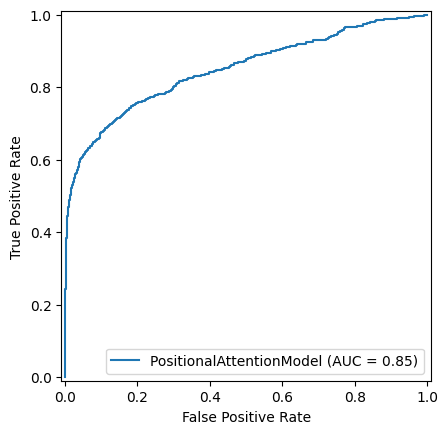

In [23]:
# Training code
VALIDATION_MODE = "independent"
if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "PATN_ProtTrans" 
    model_test(model, x_test_reshaped, y_test, model_name)
    

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import tensorflow as tf
import os
# ────────────────────────────────────────────────
#  1. Save the trained model
# ────────────────────────────────────────────────
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

model_save_path = os.path.join(save_dir, f"{model_name}_PATN_full.h5")
# model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# Optional: also save in SavedModel format (better for serving)
model.save(os.path.join(save_dir, f"{model_name}_PATN"), save_format='tf')

Model saved to: saved_models\PATN_ProtTrans_PATN_full.h5


INFO:tensorflow:Assets written to: saved_models\PATN_ProtTrans_PATN\assets


INFO:tensorflow:Assets written to: saved_models\PATN_ProtTrans_PATN\assets


# Plot T_SNE (Original ProtTrans)

Subsampling test set for visualization...
Subsampled: 100.0 positives, 300.0 negatives
Running t-SNE...
Silhouette (original): 0.1461
Silhouette (after PATN): 0.1057


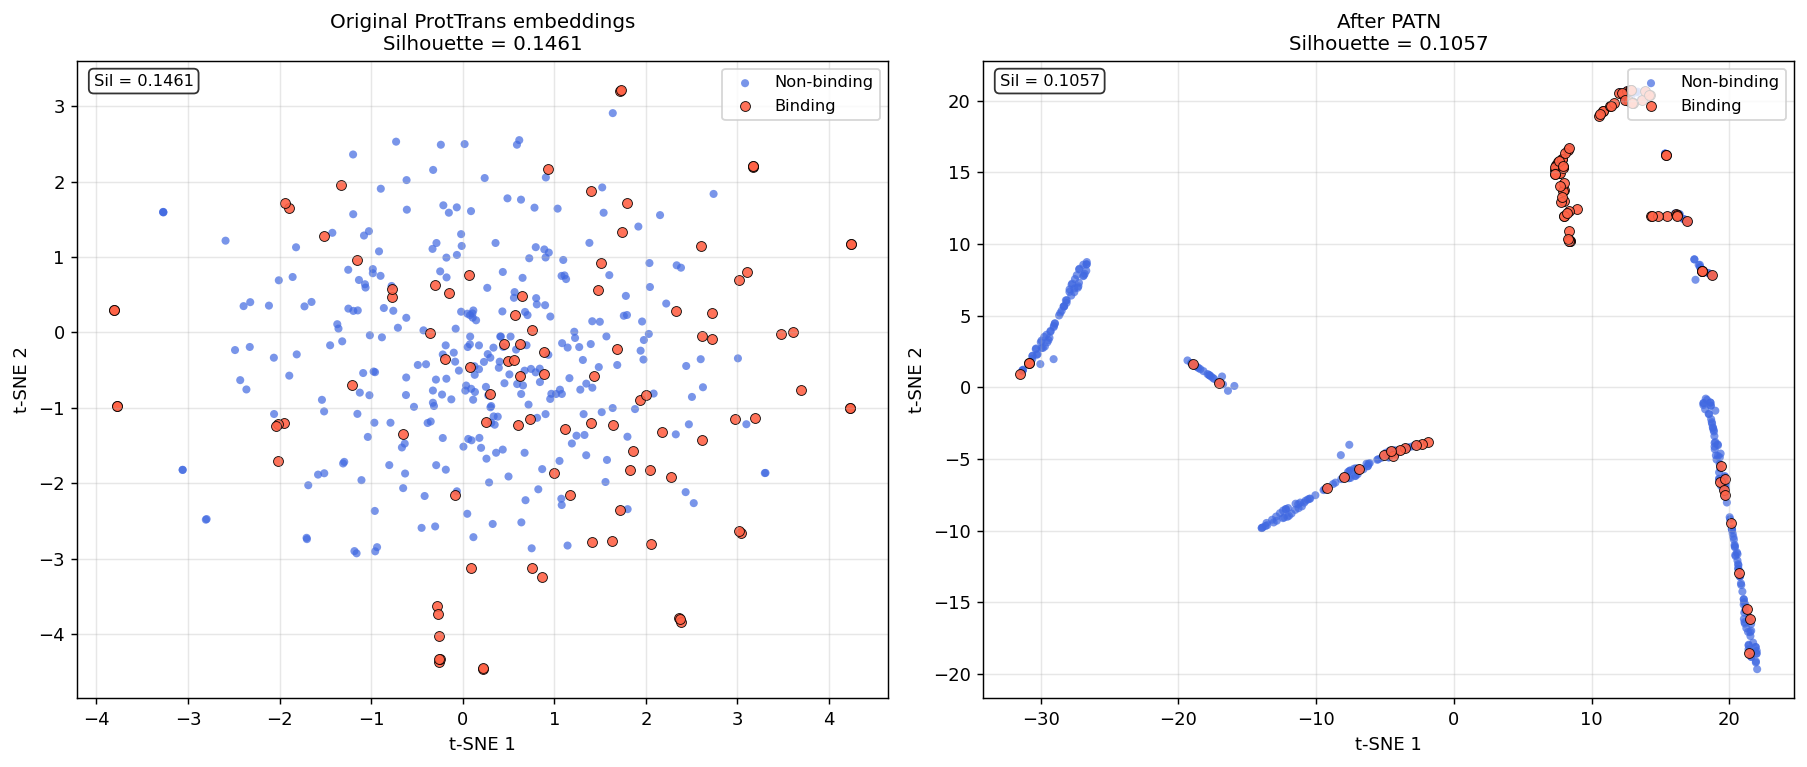

Figure saved.


In [13]:
from sklearn.metrics import silhouette_score
# ────────────────────────────────────────────────
#  2. Subsample test set (~100 pos + ~300 neg)
# Uses can change the number of positive and negative samples based on their compute source
# ────────────────────────────────────────────────
print("Subsampling test set for visualization...")

y = y_test[:, 1] if y_test.ndim == 2 else y_test.astype(np.int32)

pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

print(f"Original: {len(pos_idx)} positives, {len(neg_idx)} negatives")

n_pos = min(100, len(pos_idx))
n_neg = min(300, len(neg_idx))

# Stratified sampling
pos_sample = resample(pos_idx, n_samples=n_pos, random_state=42)
neg_sample = resample(neg_idx, n_samples=n_neg, random_state=42)

sample_idx = np.sort(np.concatenate([pos_sample, neg_sample]))

# Subsampled data
x_sub = x_test[sample_idx]              # (400, 15, 1024)
y_sub = y[sample_idx]                   # (400,)

print(f"Subsampled: {np.sum(y_sub)} positives, {len(y_sub) - np.sum(y_sub)} negatives")

# ────────────────────────────────────────────────
#  3. Extract PATN pooled features (same function as before)
# ────────────────────────────────────────────────
def get_patn_pooled_features(model, x):
    x = x.reshape(-1, SEQ_LENGTH, NUM_FEATURE)
    with tf.GradientTape(persistent=False):
        x_pe = model.positional_encoding(x)
        x_input = model.input_block(x_pe)
        x_attn = model.attention(x_input, x_input, x_input)
        x_ff = model.feed_forward(x_attn)
        pooled = model.pooling(x_ff)          # → (n, 512)
    return pooled.numpy()

X_patn_sub = get_patn_pooled_features(model, x_sub)

# Original: flatten window embeddings
X_orig_sub = x_sub.reshape(x_sub.shape[0], -1)   # (n, 15*1024)

# ────────────────────────────────────────────────
#  4. Standardize
# ────────────────────────────────────────────────
X_orig_sub = StandardScaler().fit_transform(X_orig_sub)
X_patn_sub = StandardScaler().fit_transform(X_patn_sub)

# ────────────────────────────────────────────────
#  5. t-SNE
# ────────────────────────────────────────────────
print("Running t-SNE on subsampled data...")

tsne = TSNE(
    n_components=2,
    perplexity=30,          # good for ~400 points
    learning_rate='auto',
    n_iter=1000,
    init='pca',
    random_state=42
)

X_orig_2d = tsne.fit_transform(X_orig_sub)
tsne = TSNE(                # fresh instance for second view
    n_components=2, perplexity=30, learning_rate='auto',
    n_iter=1000, init='pca', random_state=42
)
X_patn_2d = tsne.fit_transform(X_patn_sub)

# ────────────────────────────────────────────────
#  6. Plot
# ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), dpi=130)

def plot_scatter(X_2d, y, ax, title):
    pos = X_2d[y == 1]
    neg = X_2d[y == 0]
    ax.scatter(neg[:,0], neg[:,1], c='royalblue', s=20, alpha=0.7, label='Non-binding', edgecolors='none')
    ax.scatter(pos[:,0], pos[:,1], c='tomato',   s=30, alpha=0.9, label='Binding',    edgecolors='black', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plot_scatter(X_orig_2d, y_sub, ax1, "Original ProtTrans embeddings")
plot_scatter(X_patn_2d, y_sub, ax2, "After PATN")

# plt.suptitle(f"t-SNE Comparison – Subsample ({len(y_sub)} points)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Save figure
fig.savefig(f"tsne_before_after_PATN_subsample_{model_name}.png", dpi=200, bbox_inches='tight')
print("Figure saved.")

In [20]:
x_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/test_data.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/test_labels.npy", allow_pickle=True)

Subsampled: 100.0 positives, 300.0 negatives
Running t-SNE...
Silhouette (original): 0.1461
Silhouette (after PATN): 0.1057


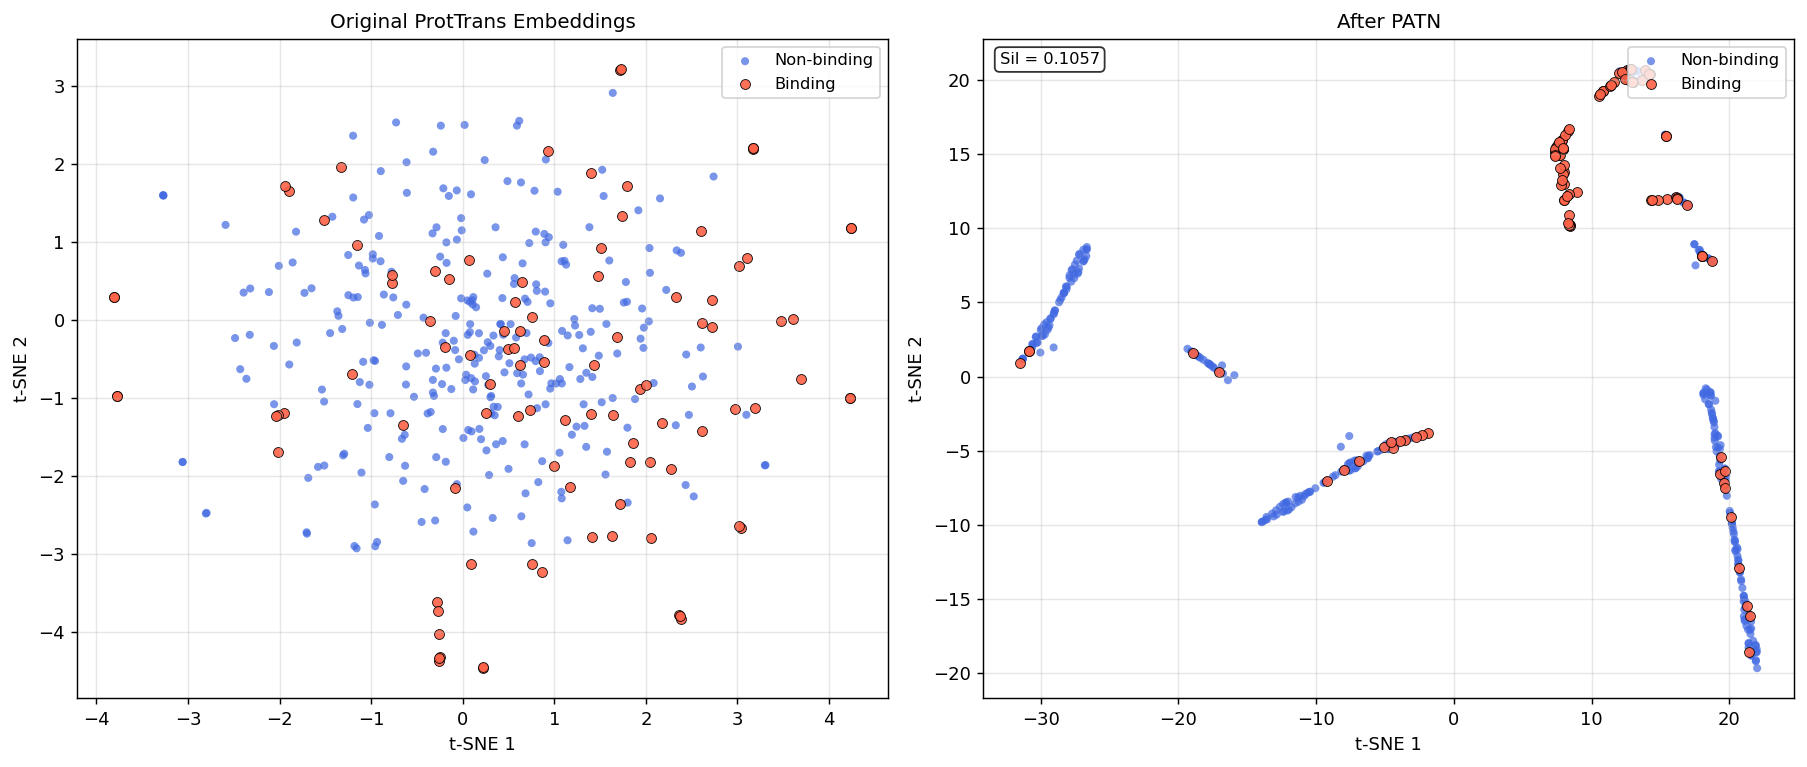

Figure saved.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import silhouette_score
import tensorflow as tf
import os

# ────────────────────────────────────────────────
#  (Assuming model is already loaded/trained,
#   x_test, y_test, model_name are available)
# ────────────────────────────────────────────────


# 2. Subsample (~100 pos + ~300 neg)
y = y_test[:, 1] if y_test.ndim == 2 else y_test.astype(np.int32)

pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

n_pos = min(100, len(pos_idx))
n_neg = min(300, len(neg_idx))

pos_sample = resample(pos_idx, n_samples=n_pos, random_state=42)
neg_sample = resample(neg_idx, n_samples=n_neg, random_state=42)

sample_idx = np.sort(np.concatenate([pos_sample, neg_sample]))

x_sub = x_test[sample_idx]
y_sub = y[sample_idx]

print(f"Subsampled: {np.sum(y_sub)} positives, {len(y_sub) - np.sum(y_sub)} negatives")

# 3. Extract PATN pooled features
def get_patn_pooled_features(model, x):
    x = x.reshape(-1, SEQ_LENGTH, NUM_FEATURE)
    with tf.GradientTape(persistent=False):
        x_pe = model.positional_encoding(x)
        x_input = model.input_block(x_pe)
        x_attn = model.attention(x_input, x_input, x_input)
        x_ff = model.feed_forward(x_attn)
        pooled = model.pooling(x_ff)
    return pooled.numpy()

X_patn_sub = get_patn_pooled_features(model, x_sub)
X_orig_sub = x_sub.reshape(x_sub.shape[0], -1)   # flattened

# 4. Standardize
X_orig_sub = StandardScaler().fit_transform(X_orig_sub)
X_patn_sub = StandardScaler().fit_transform(X_patn_sub)

# 5. t-SNE
print("Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    n_iter=1000,
    init='pca',
    random_state=42
)

X_orig_2d = tsne.fit_transform(X_orig_sub)

tsne = TSNE(  # fresh instance
    n_components=2, perplexity=30, learning_rate='auto',
    n_iter=1000, init='pca', random_state=42
)
X_patn_2d = tsne.fit_transform(X_patn_sub)

# 6. Compute silhouette scores (on 2D embeddings)
sil_orig = silhouette_score(X_orig_2d, y_sub)
sil_patn = silhouette_score(X_patn_2d, y_sub)

print(f"Silhouette (original): {sil_orig:.4f}")
print(f"Silhouette (after PATN): {sil_patn:.4f}")

# 7. Plot with silhouette in title + annotation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=130)

def plot_scatter(X_2d, y, ax, title, sil_score, flag=False):
    pos = X_2d[y == 1]
    neg = X_2d[y == 0]
    ax.scatter(neg[:,0], neg[:,1], c='royalblue', s=20, alpha=0.7, label='Non-binding', edgecolors='none')
    ax.scatter(pos[:,0], pos[:,1], c='tomato', s=30, alpha=0.9, label='Binding', edgecolors='black', linewidth=0.5)
    
    ax.set_title(f"{title}", fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Small text box with score (optional redundancy)
    if flag:
        ax.text(0.02, 0.98, f"Sil = {sil_score:.4f}",
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plot_scatter(X_orig_2d, y_sub, ax1, "Original ProtTrans Embeddings", sil_orig, False)
plot_scatter(X_patn_2d, y_sub, ax2, "After PATN", sil_patn, True)

plt.tight_layout()
plt.show()

# Save
fig.savefig(f"tsne_with_silhouette_NEW_{model_name}.png", dpi=200, bbox_inches='tight')
print("Figure saved.")

# Plot T_SNE (RAG-ProtTrans)

Subsampling test set for visualization...
Original: 634 positives, 20574 negatives
Subsampled: 100.0 positives, 300.0 negatives
Running t-SNE on subsampled data...


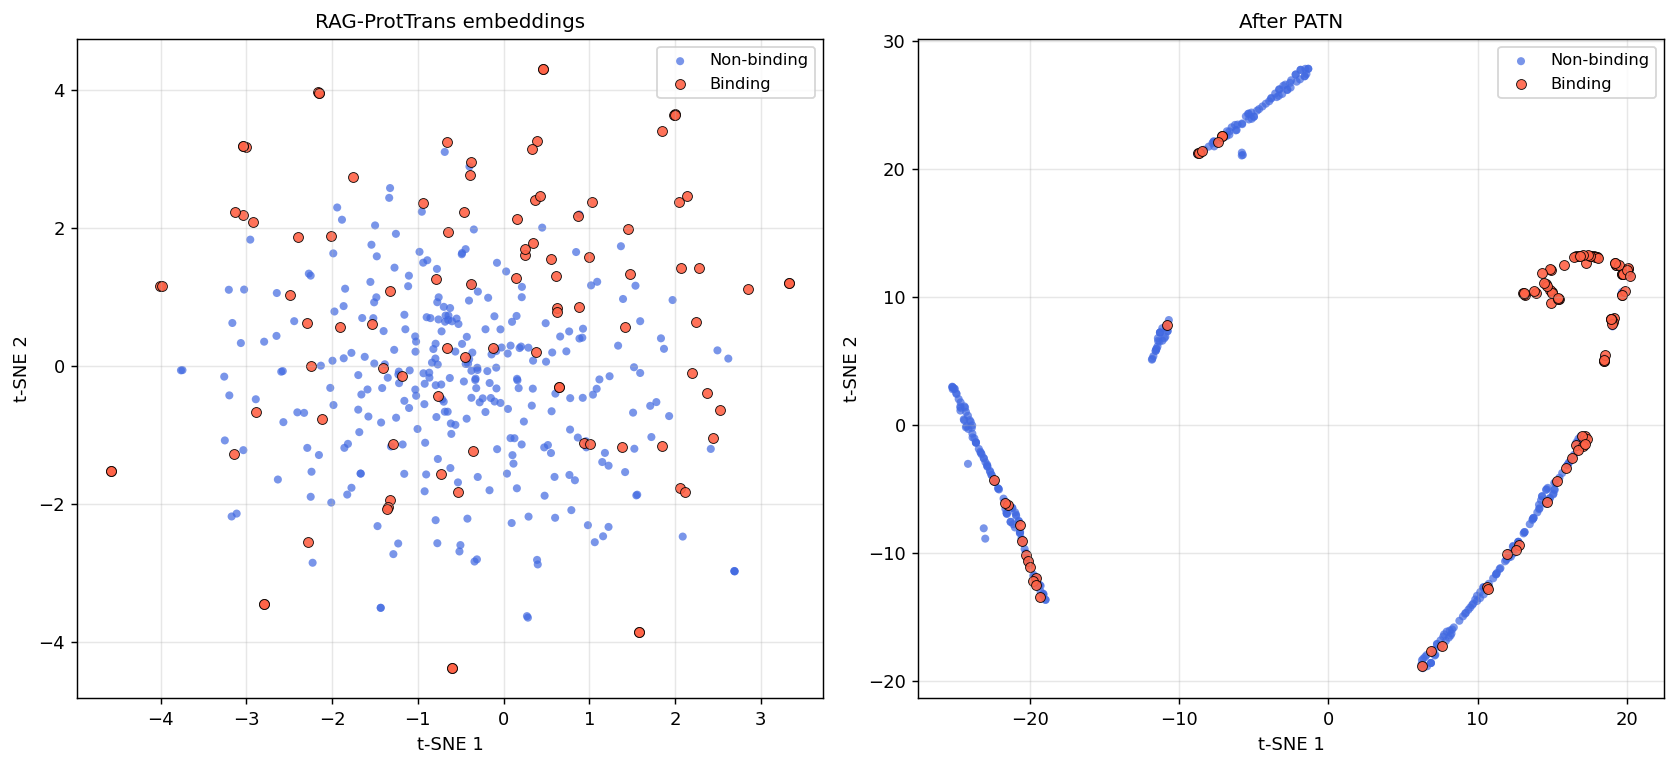

Figure saved.


In [14]:
from sklearn.metrics import silhouette_score
# ────────────────────────────────────────────────
#  2. Subsample test set (~100 pos + ~300 neg)
# ────────────────────────────────────────────────
x_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Rag_test_data_N.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/test_labels.npy", allow_pickle=True)
print("Subsampling test set for visualization...")

y = y_test[:, 1] if y_test.ndim == 2 else y_test.astype(np.int32)

pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

print(f"Original: {len(pos_idx)} positives, {len(neg_idx)} negatives")

n_pos = min(100, len(pos_idx))
n_neg = min(300, len(neg_idx))

# Stratified sampling
pos_sample = resample(pos_idx, n_samples=n_pos, random_state=42)
neg_sample = resample(neg_idx, n_samples=n_neg, random_state=42)

sample_idx = np.sort(np.concatenate([pos_sample, neg_sample]))

# Subsampled data
x_sub = x_test[sample_idx]              # (400, 15, 1024)
y_sub = y[sample_idx]                   # (400,)

print(f"Subsampled: {np.sum(y_sub)} positives, {len(y_sub) - np.sum(y_sub)} negatives")

# ────────────────────────────────────────────────
#  3. Extract PATN pooled features (same function as before)
# ────────────────────────────────────────────────
def get_patn_pooled_features(model, x):
    x = x.reshape(-1, SEQ_LENGTH, NUM_FEATURE)
    with tf.GradientTape(persistent=False):
        x_pe = model.positional_encoding(x)
        x_input = model.input_block(x_pe)
        x_attn = model.attention(x_input, x_input, x_input)
        x_ff = model.feed_forward(x_attn)
        pooled = model.pooling(x_ff)          # → (n, 512)
    return pooled.numpy()

X_patn_sub = get_patn_pooled_features(model, x_sub)

# Original: flatten window embeddings
X_orig_sub = x_sub.reshape(x_sub.shape[0], -1)   # (n, 15*1024)

# ────────────────────────────────────────────────
#  4. Standardize
# ────────────────────────────────────────────────
X_orig_sub = StandardScaler().fit_transform(X_orig_sub)
X_patn_sub = StandardScaler().fit_transform(X_patn_sub)

# ────────────────────────────────────────────────
#  5. t-SNE
# ────────────────────────────────────────────────
print("Running t-SNE on subsampled data...")

tsne = TSNE(
    n_components=2,
    perplexity=30,          # good for ~400 points
    learning_rate='auto',
    n_iter=1000,
    init='pca',
    random_state=42
)

X_orig_2d = tsne.fit_transform(X_orig_sub)
tsne = TSNE(                # fresh instance for second view
    n_components=2, perplexity=30, learning_rate='auto',
    n_iter=1000, init='pca', random_state=42
)
X_patn_2d = tsne.fit_transform(X_patn_sub)

# ────────────────────────────────────────────────
#  6. Plot
# ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), dpi=130)

def plot_scatter(X_2d, y, ax, title):
    pos = X_2d[y == 1]
    neg = X_2d[y == 0]
    ax.scatter(neg[:,0], neg[:,1], c='royalblue', s=20, alpha=0.7, label='Non-binding', edgecolors='none')
    ax.scatter(pos[:,0], pos[:,1], c='tomato',   s=30, alpha=0.9, label='Binding',    edgecolors='black', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plot_scatter(X_orig_2d, y_sub, ax1, "RAG-ProtTrans embeddings")
plot_scatter(X_patn_2d, y_sub, ax2, "After PATN")

# plt.suptitle(f"t-SNE Comparison – Subsample ({len(y_sub)} points)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Save figure
fig.savefig(f"RAG_tsne_before_after_PATN_subsample_{model_name}.png", dpi=200, bbox_inches='tight')
print("Figure saved.")

In [17]:
x_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Rag_test_data_N.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/test_labels.npy", allow_pickle=True)

Subsampled: 100.0 positives, 300.0 negatives
Running t-SNE...
Silhouette (original): 0.1839
Silhouette (after PATN): 0.1206


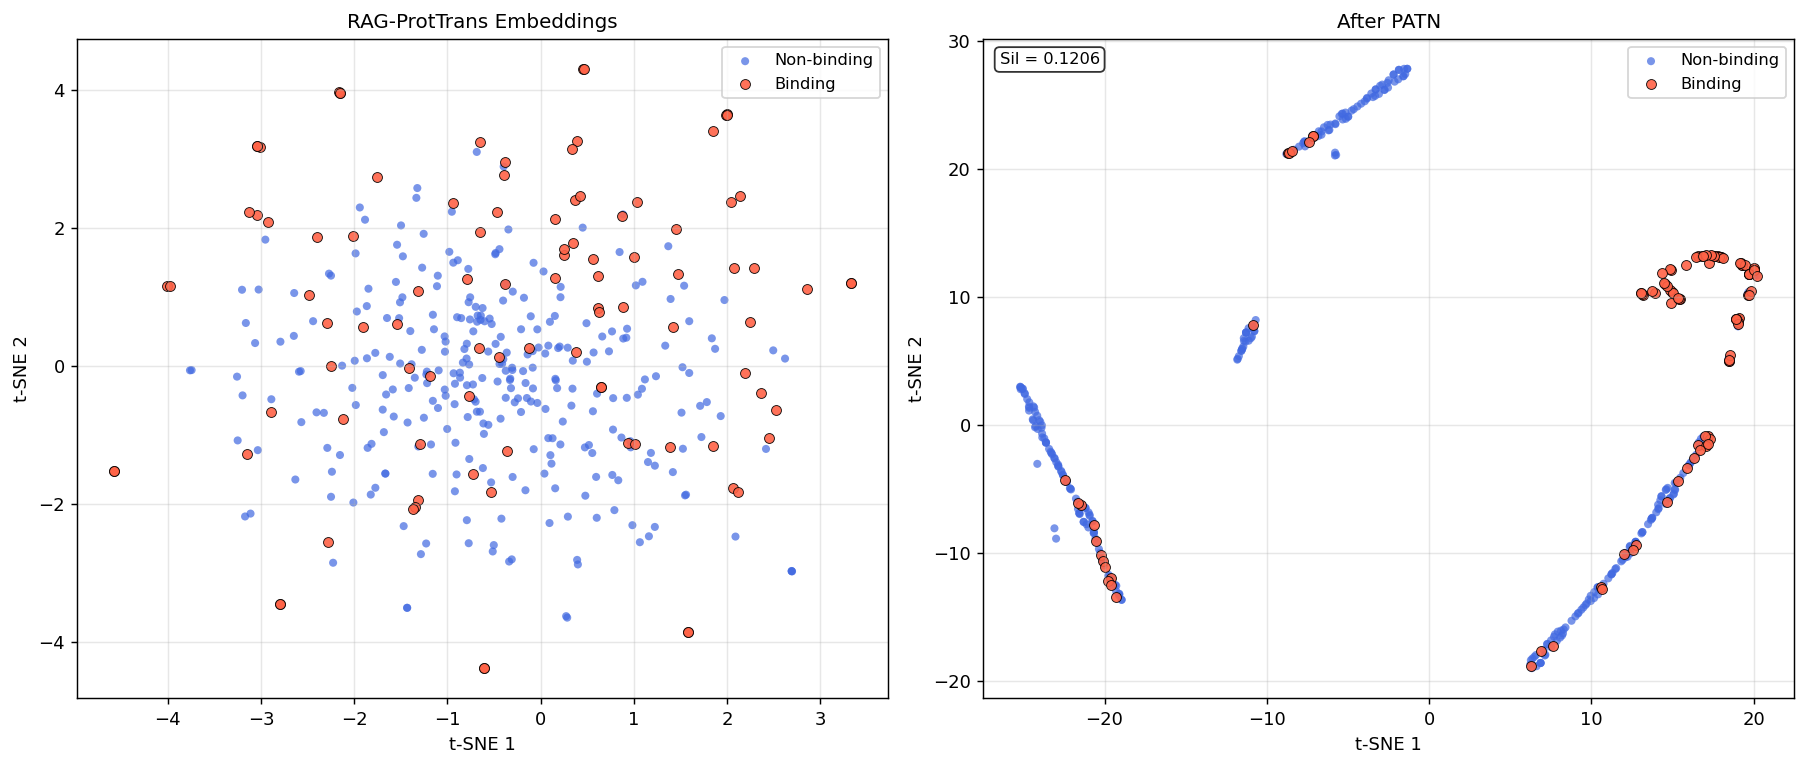

Figure saved.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import silhouette_score
import tensorflow as tf
import os

# ────────────────────────────────────────────────
#  (Assuming model is already loaded/trained,
#   x_test, y_test, model_name are available)
# ────────────────────────────────────────────────


# 2. Subsample (~100 pos + ~300 neg)
y = y_test[:, 1] if y_test.ndim == 2 else y_test.astype(np.int32)

pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

n_pos = min(100, len(pos_idx))
n_neg = min(300, len(neg_idx))

pos_sample = resample(pos_idx, n_samples=n_pos, random_state=42)
neg_sample = resample(neg_idx, n_samples=n_neg, random_state=42)

sample_idx = np.sort(np.concatenate([pos_sample, neg_sample]))

x_sub = x_test[sample_idx]
y_sub = y[sample_idx]

print(f"Subsampled: {np.sum(y_sub)} positives, {len(y_sub) - np.sum(y_sub)} negatives")

# 3. Extract PATN pooled features
def get_patn_pooled_features(model, x):
    x = x.reshape(-1, SEQ_LENGTH, NUM_FEATURE)
    with tf.GradientTape(persistent=False):
        x_pe = model.positional_encoding(x)
        x_input = model.input_block(x_pe)
        x_attn = model.attention(x_input, x_input, x_input)
        x_ff = model.feed_forward(x_attn)
        pooled = model.pooling(x_ff)
    return pooled.numpy()

X_patn_sub = get_patn_pooled_features(model, x_sub)
X_orig_sub = x_sub.reshape(x_sub.shape[0], -1)   # flattened

# 4. Standardize
X_orig_sub = StandardScaler().fit_transform(X_orig_sub)
X_patn_sub = StandardScaler().fit_transform(X_patn_sub)

# 5. t-SNE
print("Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    n_iter=1000,
    init='pca',
    random_state=42
)

X_orig_2d = tsne.fit_transform(X_orig_sub)

tsne = TSNE(  # fresh instance
    n_components=2, perplexity=30, learning_rate='auto',
    n_iter=1000, init='pca', random_state=42
)
X_patn_2d = tsne.fit_transform(X_patn_sub)

# 6. Compute silhouette scores (on 2D embeddings)
sil_orig = silhouette_score(X_orig_2d, y_sub)
sil_patn = silhouette_score(X_patn_2d, y_sub)

print(f"Silhouette (original): {sil_orig:.4f}")
print(f"Silhouette (after PATN): {sil_patn:.4f}")

# 7. Plot with silhouette in title + annotation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=130)

def plot_scatter(X_2d, y, ax, title, sil_score, flag=False):
    pos = X_2d[y == 1]
    neg = X_2d[y == 0]
    ax.scatter(neg[:,0], neg[:,1], c='royalblue', s=20, alpha=0.7, label='Non-binding', edgecolors='none')
    ax.scatter(pos[:,0], pos[:,1], c='tomato', s=30, alpha=0.9, label='Binding', edgecolors='black', linewidth=0.5)
    
    ax.set_title(f"{title}", fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Small text box with score (optional redundancy)
    if flag:
        ax.text(0.02, 0.98, f"Sil = {sil_score:.4f}",
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plot_scatter(X_orig_2d, y_sub, ax1, "RAG-ProtTrans Embeddings", sil_orig, False)
plot_scatter(X_patn_2d, y_sub, ax2, "After PATN", sil_patn, True)

plt.tight_layout()
plt.show()

# Save
fig.savefig(f"RAG_tsne_with_silhouette_NEW_{model_name}.png", dpi=200, bbox_inches='tight')
print("Figure saved.")

## Cross-Validation

Shape of y_train: (86214, 2)
Training on fold with shapes: (68971, 1, 15, 1024), (68971, 2)
Validation on fold with shapes: (17243, 1, 15, 1024), (17243, 2)
Model: "positional_attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding (Positi  multiple                 0         
 onalEncoding)                                                   
                                                                 
 sequential (Sequential)     (32, 15, 512)             526848    
                                                                 
 self_attention (SelfAttenti  multiple                 787968    
 on)                                                             
                                                                 
 sequential_1 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooli

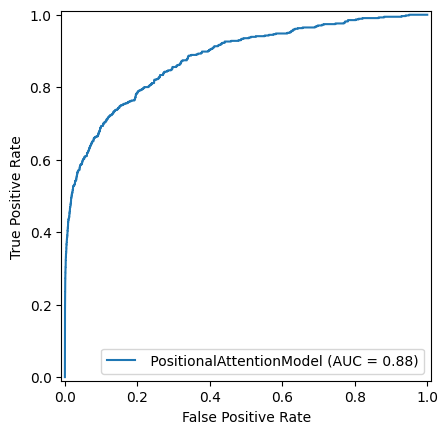

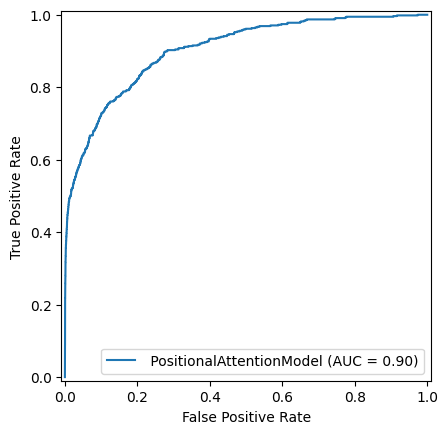

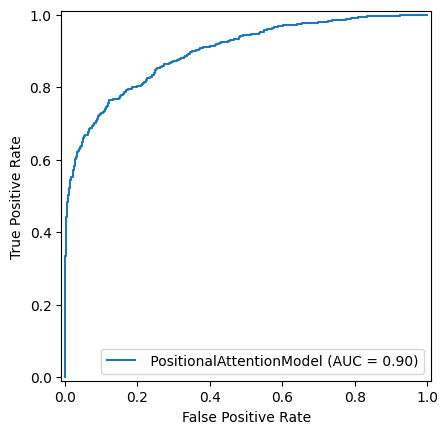

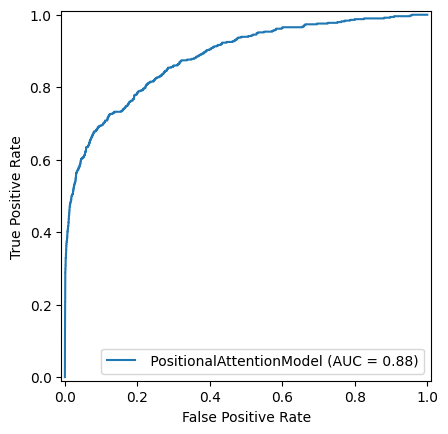

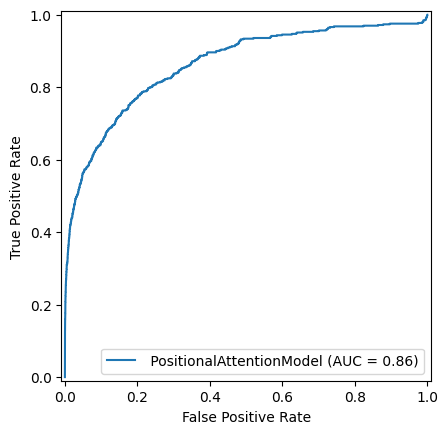

In [9]:
# Training code for the Cross-validation
if VALIDATION_MODE == "cross":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize KFold
    kf = KFold(n_splits=K_FOLD, shuffle=True, random_state=42)

    # Store metrics for each fold
    metrics_list = []

    # Cross-validation loop
    for train_index, val_index in kf.split(x_train):
        x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        # Print shapes for debugging
        print(f"Training on fold with shapes: {x_train_fold.shape}, {y_train_fold.shape}")
        print(f"Validation on fold with shapes: {x_val_fold.shape}, {y_val_fold.shape}")

        # Initialize the data generator for the training data
        generator = DataGenerator(x_train_fold, y_train_fold, batch_size=BATCH_SIZE)

        # Instantiate the AttentionOnlyModel
        model = PositionalAttention(
            feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
            hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
            num_heads=NUM_HEADS,         # Number of attention heads
            num_classes=NUM_CLASSES,     # Number of output classes (2)
            dropout_rate=DROPOUT         # Dropout rate
        )

        # Compile the model
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Build the model with the input shape expected by the DataGenerator
        model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
        
        model.summary()

        # Train the model
        history = model.fit(generator, epochs=EPOCHS, verbose=1)  # Set verbose to 1 to see training progress

        # Reshape validation data before testing
        x_val_reshaped = x_val_fold.reshape(-1, 15, 1024)  # Adjust this shape to match model input
        print(f"Reshaped Validation data shape: {x_val_reshaped.shape}")

        # Evaluate the model on the validation set using the model test function
        model_name = f"AttentionOnlyModel_fold_{len(metrics_list) + 1}"  # Create a unique name for the model
        metrics_result = model_test(model, x_val_reshaped, y_val_fold, model_name)  # Ensure y_val_fold is one-hot encoded if necessary

        # Store metrics for averaging
        metrics_list.append(metrics_result)

    # Compute average metrics
    average_metrics = np.mean(metrics_list, axis=0)
    #TP, FP, TN, FN, Sens, Spec, Acc, MCC, AUC, F1, Precision

    print(f"Average metrics over {K_FOLD} folds:")
    print(f"TP={average_metrics[0]}, FP={average_metrics[1]}, TN={average_metrics[2]}, FN={average_metrics[3]}")
    print(f"Sensitivity={average_metrics[4]:.4f}, Specificity={average_metrics[5]:.4f}, "
          f"Accuracy={average_metrics[6]:.4f}, MCC={average_metrics[7]:.4f}, "
          f"AUC={average_metrics[8]:.4f}, F1={average_metrics[9]:.4f}, Precision={average_metrics[10]:.4f}")


## New Independent Test Set

In [6]:
import numpy as np
x_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/train_data.npy", allow_pickle=True)
y_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/train_labels.npy", allow_pickle=True)
x_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Indep_test_data.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Indep_test_labels.npy", allow_pickle=True)

In [7]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test .shape)

(86214, 1, 15, 1024)
(86214, 2)
(2275, 1, 15, 1024)
(2275, 2)


Shape of y_train: (86214, 2)
Model: "positional_attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding (Positi  multiple                 0         
 onalEncoding)                                                   
                                                                 
 sequential (Sequential)     (32, 15, 512)             526848    
                                                                 
 self_attention (SelfAttenti  multiple                 787968    
 on)                                                             
                                                                 
 sequential_1 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d (G  multiple                 0         
 lobalAveragePooling1D)                                          
                 

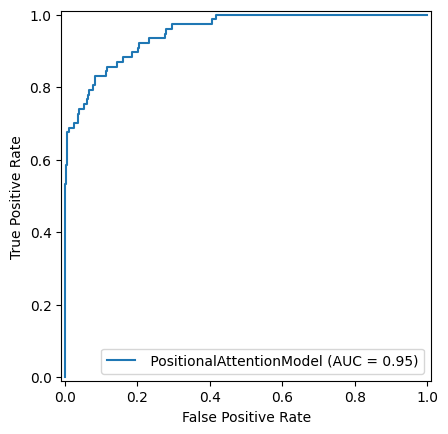

In [8]:
# Training code
if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "PATN_New_Test Set" 
    model_test(model, x_test_reshaped, y_test, model_name)

## RAG Feature Fusion Test

In [11]:
import numpy as np
x_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Rag_train_data_N.npy", allow_pickle=True)
y_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/train_labels.npy", allow_pickle=True)
x_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Rag_test_data_N.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/test_labels.npy", allow_pickle=True)

In [12]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test .shape)

(86214, 1, 15, 1024)
(86214, 2)
(21208, 1, 15, 1024)
(21208, 2)


Shape of y_train: (86214, 2)
Model: "positional_attention_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding_11 (Pos  multiple                 0         
 itionalEncoding)                                                
                                                                 
 sequential_22 (Sequential)  (32, 15, 512)             526848    
                                                                 
 self_attention_11 (SelfAtte  multiple                 787968    
 ntion)                                                          
                                                                 
 sequential_23 (Sequential)  (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d_11  multiple                 0         
  (GlobalAveragePooling1D)                                       
              

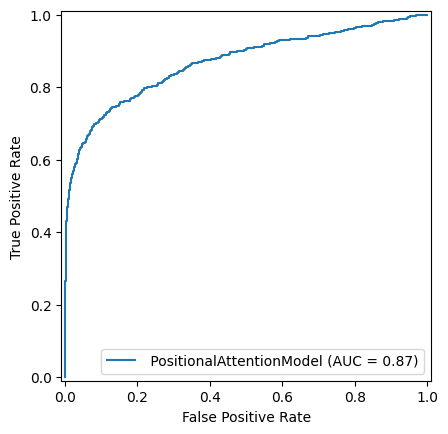

In [14]:
# Training code for RAG Test Data
VALIDATION_MODE = "independent"
if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "PATN_RAG_Test_N" 
    model_test(model, x_test_reshaped, y_test, model_name)

Shape of y_train: (86214, 2)
Training on fold with shapes: (68971, 1, 15, 1024), (68971, 2)
Validation on fold with shapes: (17243, 1, 15, 1024), (17243, 2)
Model: "positional_attention_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding_6 (Posi  multiple                 0         
 tionalEncoding)                                                 
                                                                 
 sequential_12 (Sequential)  (32, 15, 512)             526848    
                                                                 
 self_attention_6 (SelfAtten  multiple                 787968    
 tion)                                                           
                                                                 
 sequential_13 (Sequential)  (32, 15, 512)             525312    
                                                                 
 global_average_poo

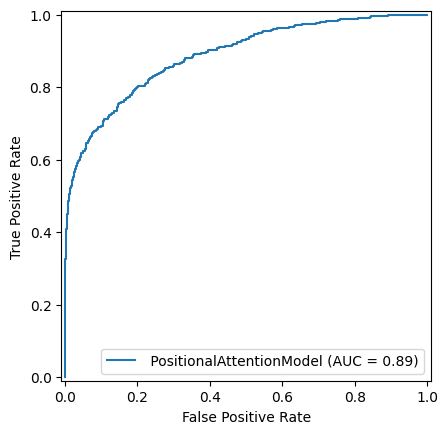

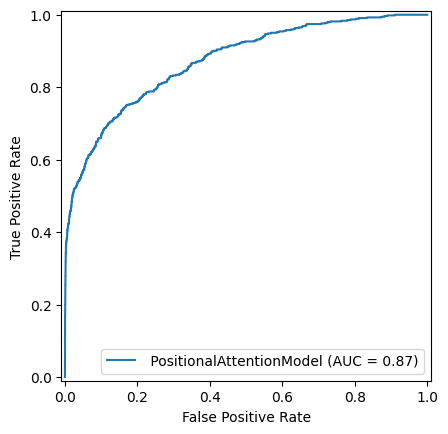

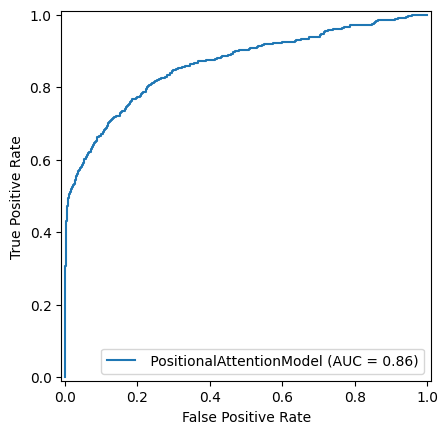

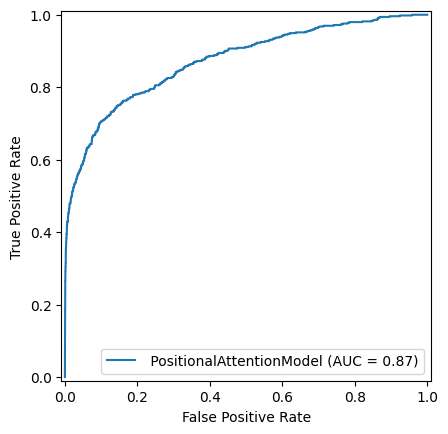

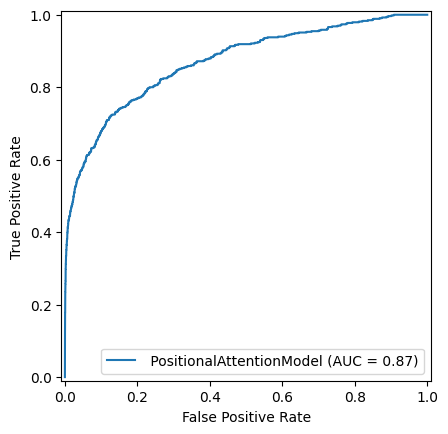

In [13]:
##Cross Validation
VALIDATION_MODE="cross"
# Training code for the Cross-validation
if VALIDATION_MODE == "cross":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize KFold
    kf = KFold(n_splits=K_FOLD, shuffle=True, random_state=42)

    # Store metrics for each fold
    metrics_list = []

    # Cross-validation loop
    for train_index, val_index in kf.split(x_train):
        x_train_fold, x_val_fold = x_train[train_index], x_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        # Print shapes for debugging
        print(f"Training on fold with shapes: {x_train_fold.shape}, {y_train_fold.shape}")
        print(f"Validation on fold with shapes: {x_val_fold.shape}, {y_val_fold.shape}")

        # Initialize the data generator for the training data
        generator = DataGenerator(x_train_fold, y_train_fold, batch_size=BATCH_SIZE)

        # Instantiate the AttentionOnlyModel
        model = PositionalAttention(
            feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
            hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
            num_heads=NUM_HEADS,         # Number of attention heads
            num_classes=NUM_CLASSES,     # Number of output classes (2)
            dropout_rate=DROPOUT         # Dropout rate
        )

        # Compile the model
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        # Build the model with the input shape expected by the DataGenerator
        model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
        
        model.summary()

        # Train the model
        history = model.fit(generator, epochs=EPOCHS, verbose=1)  # Set verbose to 1 to see training progress

        # Reshape validation data before testing
        x_val_reshaped = x_val_fold.reshape(-1, 15, 1024)  # Adjust this shape to match model input
        print(f"Reshaped Validation data shape: {x_val_reshaped.shape}")

        # Evaluate the model on the validation set using the model test function
        model_name = f"PATN_RAG__N_Cross_fold_{len(metrics_list) + 1}"  # Create a unique name for the model
        metrics_result = model_test(model, x_val_reshaped, y_val_fold, model_name)  # Ensure y_val_fold is one-hot encoded if necessary

        # Store metrics for averaging
        metrics_list.append(metrics_result)

    # Compute average metrics
    average_metrics = np.mean(metrics_list, axis=0)

    print(f"Average metrics over {K_FOLD} folds:")
    print(f"TP={average_metrics[0]}, FP={average_metrics[1]}, TN={average_metrics[2]}, FN={average_metrics[3]}")
    print(f"Sensitivity={average_metrics[4]:.4f}, Specificity={average_metrics[5]:.4f}, "
          f"Accuracy={average_metrics[6]:.4f}, Precision={average_metrics[7]:.4f}, "
          f"AUC={average_metrics[8]:.4f}, MCC={average_metrics[9]:.4f}, F1={average_metrics[10]:.4f}")


In [31]:
import numpy as np
x_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Rag_train_data_N.npy", allow_pickle=True)
y_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/train_labels.npy", allow_pickle=True)
x_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Rag_Indp_test_data_N.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Indep_test_labels.npy", allow_pickle=True)

In [32]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test .shape)

(86214, 1, 15, 1024)
(86214, 2)
(2275, 1, 15, 1024)
(2275, 2)


Shape of y_train: (86214, 2)
Model: "positional_attention_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding_13 (Pos  multiple                 0         
 itionalEncoding)                                                
                                                                 
 sequential_26 (Sequential)  (32, 15, 512)             526848    
                                                                 
 self_attention_13 (SelfAtte  multiple                 787968    
 ntion)                                                          
                                                                 
 sequential_27 (Sequential)  (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d_13  multiple                 0         
  (GlobalAveragePooling1D)                                       
              

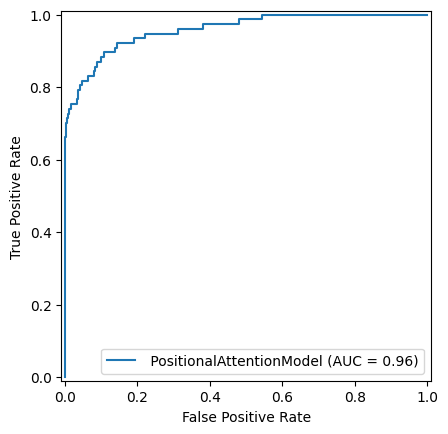

In [33]:
# New testing data
VALIDATION_MODE="independent"
if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "PATN_New_RAG_N_Test Set" 
    model_test(model, x_test_reshaped, y_test, model_name)

In [17]:
1+1

2